# Task XI - Classical-Quantum Embedding with PQC

This task implements a simple embedding pipeline using a neural network (MLP) to estimate parameters for a Parameterized Quantum Circuit (PQC). The input data is sampled from a normal distribution, and the PQC prepares quantum states based on the estimated parameters. Training uses MSE loss.

## Steps
1. Generate normally distributed input data.
2. Use an MLP (2-3 linear layers) to estimate PQC parameters.
3. Prepare quantum states with 4-5 qubits using the estimated parameters.
4. Train the model using MSE loss.


In [2]:
!pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 41.1 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cirq
import matplotlib.pyplot as plt

In [5]:
import os
os.makedirs('task11', exist_ok=True)
print("Directory 'task11' created successfully.")

Directory 'task11' created successfully.


Epoch 5, Loss: 1.1241
Epoch 10, Loss: 1.1081
Epoch 15, Loss: 1.0948
Epoch 20, Loss: 1.0834
Sample PQC circuit:
(0, 0): ───Rx(0.0227π)───

(0, 1): ───Rx(0.0326π)───

(0, 2): ───Rx(0.0478π)───

(0, 3): ───Rx(0.0119π)───

(0, 4): ───Rx(0.0411π)───
Sample PQC circuit saved as task11/pqc_sample.svg


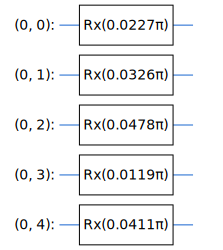

In [7]:
# Generate normally distributed data
N = 200
input_dim = 8
X = np.random.normal(0, 1, size=(N, input_dim))
Y = np.random.normal(0, 1, size=(N, 5))  # Target PQC parameters (for demonstration)

# MLP to estimate PQC parameters
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# PQC: 5 qubits, RX rotations

def pqc_state(params):
    qubits = [cirq.GridQubit(0, i) for i in range(5)]
    circuit = cirq.Circuit()
    for i, qubit in enumerate(qubits):
        circuit.append(cirq.rx(params[i])(qubit))
    return circuit, qubits

# Training

def train_embedding():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    Y_tensor = torch.tensor(Y, dtype=torch.float32).to(device)
    model = MLP(input_dim, 5).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(20):
        model.train()
        optimizer.zero_grad()
        pred = model(X_tensor)
        loss = criterion(pred, Y_tensor)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # Visualize PQC for one sample
    params = model(X_tensor[:1]).detach().cpu().numpy()[0]
    circuit, qubits = pqc_state(params)
    print("Sample PQC circuit:")
    print(circuit)
    # Save circuit diagram
    from cirq.contrib.svg import circuit_to_svg
    from IPython.display import SVG, display
    svg = circuit_to_svg(circuit)
    with open("task11/pqc_sample.svg", "w", encoding="utf-8") as f:
        f.write(svg)
    print("Sample PQC circuit saved as task11/pqc_sample.svg")
    display(SVG(svg))

if __name__ == "__main__":
    train_embedding()
